# 6.2 Metadata Trial 003: Feature Importance

Purpose:
- Interpret the accepted metadata baseline.
- Identify which risk-factor variables contribute most.
- Confirm whether the model is learning medically plausible signals.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent))

from rural_stroke_assist.config import (
    METADATA_SPLIT_MANIFEST_PATH,
    METADATA_TRIAL_001_MODEL_PATH,
    METADATA_TRIAL_003_FEATURE_IMPORTANCE_PATH,
    METADATA_TRIAL_003_FEATURE_IMPORTANCE_FIGURE_PATH,
    METADATA_TRIAL_003_RESULTS_PATH,
)

from rural_stroke_assist.preprocessing.metadata import (
    prepare_metadata_modeling_frame,
    split_metadata_features_target,
)

from rural_stroke_assist.modeling.metadata_baselines import (
    load_metadata_model,
    compute_metadata_permutation_importance,
)

In [2]:
metadata_df = pd.read_csv(METADATA_SPLIT_MANIFEST_PATH)
metadata_model_df = prepare_metadata_modeling_frame(metadata_df)

test_df = metadata_model_df[metadata_model_df["split"] == "test"].copy()

X_test, y_test = split_metadata_features_target(test_df)

X_test.head()

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender,ever_married,work_type,Residence_type,smoking_status
5,81.0,0,0,186.21,29.0,Male,Yes,Private,Urban,formerly smoked
24,71.0,0,0,102.87,27.2,Male,Yes,Private,Urban,formerly smoked
31,42.0,0,0,83.41,25.4,Male,Yes,Private,Rural,Unknown
51,78.0,1,0,75.32,NaN,Male,Yes,Private,Urban,formerly smoked
53,77.0,1,0,124.13,31.4,Female,Yes,Self-employed,Urban,never smoked


In [3]:
model = load_metadata_model(METADATA_TRIAL_001_MODEL_PATH)

model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'hypertension',
                                                   'heart_disease',
                                                   'avg_glucose_level',
                                                   'bmi']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'ever_married',
                                                   'work_type',
                                                   'Residence_type',
                                                   'smoking_status'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [4]:
importance_df = compute_metadata_permutation_importance(
    model=model,
    X_test=X_test,
    y_test=y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=42,
)

importance_df

,feature,importance_mean,importance_std
0,age,0.322164,0.061256
1,hypertension,0.010940,0.003692
2,work_type,0.007996,0.006694
3,avg_glucose_level,0.006884,0.003631
4,heart_disease,0.000597,0.001029
5,Residence_type,0.000348,0.000448
6,bmi,0.000301,0.000126
7,ever_married,0.000027,0.000693
8,gender,-0.001168,0.002059
9,smoking_status,-0.003558,0.003562


In [5]:
METADATA_TRIAL_003_FEATURE_IMPORTANCE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

importance_df.to_csv(
    METADATA_TRIAL_003_FEATURE_IMPORTANCE_PATH,
    index=False,
)

METADATA_TRIAL_003_FEATURE_IMPORTANCE_PATH

WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/data/processed/experiments/metadata_trial_003_feature_importance.csv')

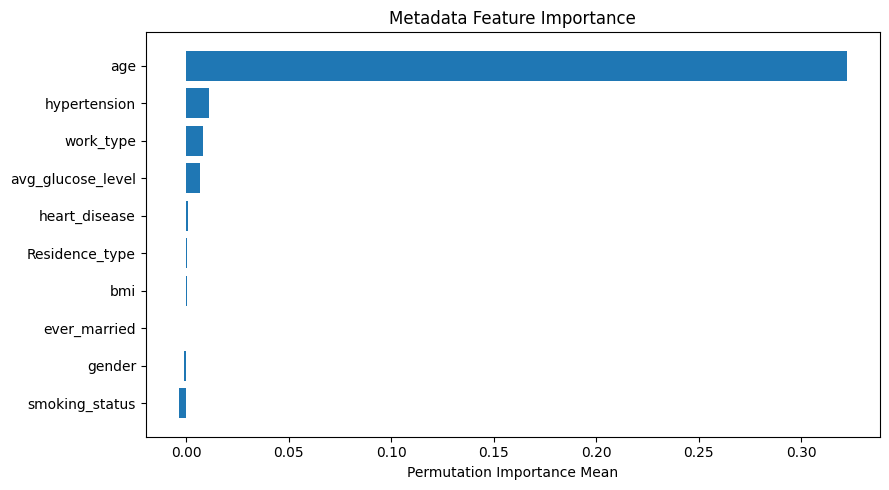

In [6]:
top_features = importance_df.head(10)

plt.figure(figsize=(9, 5))
plt.barh(top_features["feature"], top_features["importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance Mean")
plt.title("Metadata Feature Importance")
plt.tight_layout()
plt.show()

In [7]:
METADATA_TRIAL_003_FEATURE_IMPORTANCE_FIGURE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

plt.figure(figsize=(9, 5))
plt.barh(top_features["feature"], top_features["importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation Importance Mean")
plt.title("Metadata Feature Importance")
plt.tight_layout()
plt.savefig(METADATA_TRIAL_003_FEATURE_IMPORTANCE_FIGURE_PATH)
plt.close()

METADATA_TRIAL_003_FEATURE_IMPORTANCE_FIGURE_PATH

WindowsPath('C:/Users/Asus/Downloads/Uni_work/Grad-Project/rural-stroke-assist/reports/figures/experiments/metadata_trial_003_feature_importance.png')

In [8]:
top_feature_lines = "\n".join(
    [
        f"- {row.feature}: {row.importance_mean:.4f}"
        for row in importance_df.head(10).itertuples()
    ]
)

report = f"""# Metadata Trial 003 Feature Importance

## Purpose

This experiment analyzes which metadata variables contribute most to the accepted metadata baseline.

## Top Features

{top_feature_lines}

## Interpretation

The metadata model is interpreted as a contextual stroke-risk model, not an acute stroke triage model.

Features such as age, average glucose level, hypertension, heart disease, BMI, and smoking status are risk-factor variables. They can provide contextual risk evidence, but they do not directly indicate whether a patient is currently experiencing an acute stroke.

## Decision

Feature importance analysis is accepted as part of the metadata MVP documentation.

The model remains useful only as a contextual risk component inside the future fusion system.
"""

METADATA_TRIAL_003_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
METADATA_TRIAL_003_RESULTS_PATH.write_text(report, encoding="utf-8")

print(report)

# Metadata Trial 003 Feature Importance

## Purpose

This experiment analyzes which metadata variables contribute most to the accepted metadata baseline.

## Top Features

- age: 0.3222
- hypertension: 0.0109
- work_type: 0.0080
- avg_glucose_level: 0.0069
- heart_disease: 0.0006
- Residence_type: 0.0003
- bmi: 0.0003
- ever_married: 0.0000
- gender: -0.0012
- smoking_status: -0.0036

## Interpretation

The metadata model is interpreted as a contextual stroke-risk model, not an acute stroke triage model.

Features such as age, average glucose level, hypertension, heart disease, BMI, and smoking status are risk-factor variables. They can provide contextual risk evidence, but they do not directly indicate whether a patient is currently experiencing an acute stroke.

## Decision

Feature importance analysis is accepted as part of the metadata MVP documentation.

The model remains useful only as a contextual risk component inside the future fusion system.

